In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("milknew.csv")
df_original = df.copy()
df.head(3)

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low


In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("numeric columns:", numeric_cols)
print("object/categorical columns:", object_cols)

numeric columns: ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour']
object/categorical columns: ['Grade']


In [13]:
desc = df[numeric_cols].agg(['mean','std','min','max'])
quartiles = df[numeric_cols].quantile([0.25,0.5,0.75]).T
summary = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'std': df[numeric_cols].std(),
    'min': df[numeric_cols].min(),
    'q1': df[numeric_cols].quantile(0.25),
    'q2_median': df[numeric_cols].median(),
    'q3': df[numeric_cols].quantile(0.75),
    'max': df[numeric_cols].max()
})
summary


,mean,std,min,q1,q2_median,q3,max
pH,6.630123,1.399679,3.0,6.5,6.7,6.8,9.5
Temprature,44.226629,10.098364,34.0,38.0,41.0,45.0,90.0
Taste,0.546742,0.498046,0.0,0.0,1.0,1.0,1.0
Odor,0.432483,0.495655,0.0,0.0,0.0,1.0,1.0
Fat,0.671388,0.469930,0.0,0.0,1.0,1.0,1.0
Turbidity,0.491029,0.500156,0.0,0.0,0.0,1.0,1.0
Colour,251.840415,4.307424,240.0,250.0,255.0,255.0,255.0


In [7]:
df[numeric_cols].head(10)


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
0,6.6,35,1,0,1,0,254
1,6.6,36,0,1,0,1,253
2,8.5,70,1,1,1,1,246
3,9.5,34,1,1,0,1,255
4,6.6,37,0,0,0,0,255
5,6.6,37,1,1,1,1,255
6,5.5,45,1,0,1,1,250
7,4.5,60,0,1,1,1,250
8,8.1,66,1,0,1,1,255
9,6.7,45,1,1,0,0,247


In [8]:
n_records = df.shape[0]
n_attributes = df.shape[1]
attribute_names = df.columns.tolist()
n_numeric_attributes = len(numeric_cols)

info_table = {
    'n_records': n_records,
    'n_attributes': n_attributes,
    'numeric_attributes_count': n_numeric_attributes,
    'attribute_names': attribute_names
}
info_table

{'n_records': 1059,
 'n_attributes': 8,
 'numeric_attributes_count': 7,
 'attribute_names': ['pH',
  'Temprature',
  'Taste',
  'Odor',
  'Fat ',
  'Turbidity',
  'Colour',
  'Grade']}

In [9]:
object_counts = {}
for col in object_cols:
    object_counts[col] = df[col].value_counts(dropna=False)
# tampilkan ringkasan singkat
for col, counts in object_counts.items():
    print(f"--- {col} ---")
    print(counts)
    print()

--- Grade ---
Grade
low       429
medium    374
high      256
Name: count, dtype: int64



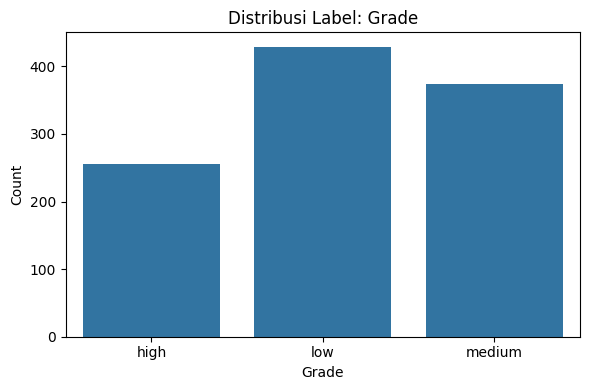

In [11]:
if 'Grade' in df.columns or 'grade' in [c.lower() for c in df.columns]:
    grade_col = 'Grade' if 'Grade' in df.columns else [c for c in df.columns if c.lower()=='grade'][0]
    plt.figure(figsize=(6,4))
    sns.countplot(x=grade_col, data=df, order=sorted(df[grade_col].dropna().unique()))
    plt.title('Distribusi Label: ' + grade_col)
    plt.xlabel(grade_col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak menemukan kolom 'Grade' untuk distribusi label")
    if object_cols:
        plt.figure(figsize=(6,4))
        sns.countplot(x=object_cols[0], data=df)
        plt.title('Distribusi: ' + object_cols[0])
        plt.tight_layout()
        plt.show()

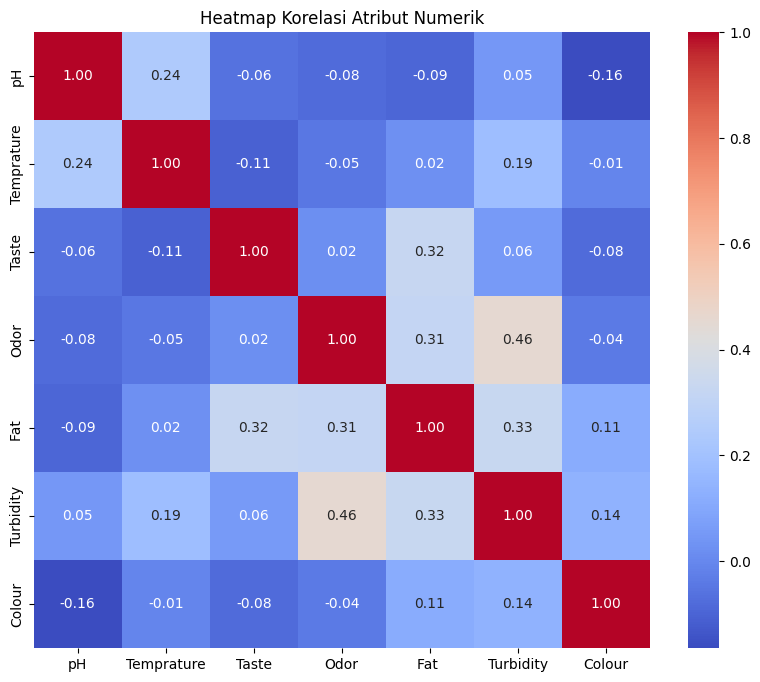

In [12]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Heatmap Korelasi Atribut Numerik")
plt.show()

## Kesimpulan Analisis Dataset Milk Quality

1. Dataset terdiri dari 1059 record dengan 8 atribut (7 numerik dan 1 kategorikal).
2. Atribut `Grade` memiliki 3 label kualitas susu: high, medium, low.
3. Distribusi pH berperan penting dalam menentukan kualitas susu. Susu dengan pH normal cenderung memiliki Grade tinggi, sedangkan pH tinggi atau terlalu rendah banyak muncul pada Grade rendah.
4. Faktor lain seperti `Odor`, `Fat`, dan `Turbidity` juga mempengaruhi kualitas, meskipun korelasinya lebih rendah dibanding pH.
5. Visualisasi heatmap memperlihatkan bahwa tidak semua variabel saling berkorelasi kuat, sehingga kualitas susu dipengaruhi oleh kombinasi beberapa faktor.
